**Given data consisting of real and fake tweets with labels, a machine learning model is built for fake tweet detection. The data is preprocessed and split into tokens. Feature vectorisation is then done and a weight is assigned according to the occurrence of the word. After that cross validation is done, where the data is split in ten folds. Using an appropriate index in a loop, the train and validation data are assigned. Train data is trained using support vector algorithm. The labels for the validation data are predicted using the classifier. Then the accuracy is calculated and a confusion matrix is plotted. Error analysis is done after this to check out the number of false positive and negative values. Finally, the classifier is used to predict the labels for the test data. ******

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/nlp-getting-started/sample_submission.csv
/kaggle/input/nlp-getting-started/train.csv
/kaggle/input/nlp-getting-started/test.csv


In [2]:
from sklearn import metrics                            # csv reader
from sklearn.svm import LinearSVC
from nltk.classify import SklearnClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import precision_recall_fscore_support # to report on precision and recall
import numpy as np
import re
from sklearn.metrics import classification_report
from sklearn.model_selection import cross_val_score
from sklearn import svm
import nltk
nltk.download('omw-1.4')
nltk.download('stopwords')
from nltk.stem import WordNetLemmatizer
from nltk.corpus import stopwords
import warnings
warnings.filterwarnings("ignore")  
from sklearn.metrics import accuracy_score
from collections import Counter, OrderedDict
from nltk.util import ngrams
import string
import re
import csv
from xgboost import XGBClassifier

[nltk_data] Downloading package omw-1.4 to /usr/share/nltk_data...
[nltk_data] Downloading package stopwords to /usr/share/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [3]:
def load_data(path):
    """Load training data from file and append it to raw_data1."""
    raw_data1 = []
    with open(path) as f:
        reader1 = csv.reader(f)
        for line in reader1:

            (text, label) = parse_data_line(line)

            raw_data1.append((text, label))
  
            
    return raw_data1

In [4]:
def parse_data_line(data_line):
    return(data_line[3], data_line[4])

In [5]:
def preprocess_data(raw_data1, raw_data2):
    """Do pre processing and feature extraction on training and test data. Append 
    the label to train data. ."""
    for (text, label) in raw_data1:
     global train_data
     train_data.append(((to_feature_vector(pre_process(text))),label))
    for text in raw_data2:
     test_data.append((to_feature_vector(pre_process(text))))
        
        

For preprocessing, individual functions doing various operations are executed when pre_process function is called. This is done by keeping all switches to ON state. Functiontext2int converts string to integers. Current value is incremented according to position and string is returned. In other functions, further preprocessing is done by replacing all non word characters are replaced with a blank space. The text is split into tokens which are converted into lower case. Stop words are removed and lemmatisation is done

In [6]:
preprocessing_switches = {
        "convert_usernames" : True,
        "separate_out_punctuation" : True,
        "convert_number_words_to_digits": True,
        "convert_numbers" : True,
        "remove_punctuation" : True,
        "convert_to_lowercase" : True,
        "remove_stopwords" : True,
        "apply_lemmatization" : True
    }

In [7]:
def text2int(textnum, numwords={}):
    if not numwords:
        units = [
        "zero", "one", "two", "three", "four", "five", "six", "seven", "eight",
        "nine", "ten", "eleven", "twelve", "thirteen", "fourteen", "fifteen",
        "sixteen", "seventeen", "eighteen", "nineteen",
        ]

        tens = ["", "", "twenty", "thirty", "forty", "fifty", "sixty", "seventy", "eighty", "ninety"]

        scales = ["hundred", "thousand", "million", "billion", "trillion"]

        numwords["and"] = (1, 0)
        for idx, word in enumerate(units):  numwords[word] = (1, idx)
        for idx, word in enumerate(tens):       numwords[word] = (1, idx * 10)
        for idx, word in enumerate(scales): numwords[word] = (10 ** (idx * 3 or 2), 0)

    ordinal_words = {'first':1, 'second':2, 'third':3, 'fifth':5, 'eighth':8, 'ninth':9, 'twelfth':12}
    ordinal_endings = [('ieth', 'y'), ('th', '')]

    textnum = textnum.replace('-', ' ')

    current = result = 0
    curstring = ""
    onnumber = False
    for word in textnum.split():
        if word in ordinal_words:
            scale, increment = (1, ordinal_words[word])
            current = current * scale + increment
            if scale > 100:
                result += current
                current = 0
            onnumber = True
        else:
            for ending, replacement in ordinal_endings:
                if word.endswith(ending):
                    word = "%s%s" % (word[:-len(ending)], replacement)
            if word not in numwords:
                if onnumber:
                    curstring += repr(result + current) + " "
                curstring += word + " "
                result = current = 0
                onnumber = False
            else:
                scale, increment = numwords[word]

                current = current * scale + increment
                if scale > 100:
                    result += current
                    current = 0
                onnumber = True

    if onnumber:
        curstring += repr(result + current)

    return curstring

def tokenize_text(text):
    if preprocessing_switches["separate_out_punctuation"]:
        text = re.sub(r"(\w)([.,;:!?'\"”\)])", r"\1 \2", text) # separates punctuation at ends of strings
        text = re.sub(r"([.,;:!?'\"“\(\)])(\w)", r"\1 \2", text) # separates punctuation at beginning of strings
    if preprocessing_switches["convert_numbers"]:
        text = re.sub('\d+', 'NUMBER',text)
    # print("tokenising:", text) # uncomment for debugging
    tokens = text.split()
    return tokens

def remove_characters_after_tokenization(tokens):
    # note preserving critical social media/twitter characters @ and #
    p = '[{}]'.format(re.escape(string.punctuation)+'\…').replace("@", "").replace("\#", "")
    #print(p)
    pattern = re.compile(p)
    filtered_tokens = [f for f in filter(None, [pattern.sub('', token) for token in tokens])]
    return filtered_tokens

def convert_to_lowercase(tokens):
    return [token.lower() for token in tokens if token.isalpha()]

def remove_stopwords(tokens):
    stopword_list = nltk.corpus.stopwords.words('english')
    filtered_tokens = [token for token in tokens if token not in stopword_list]
    return filtered_tokens

def apply_lemmatization(tokens, wnl=WordNetLemmatizer()):   
    return [wnl.lemmatize(token) for token in tokens]

def pre_process(text):
    """ Technique which will apply the techniques if they are set to 
    True in the global dict ::preprocessing_switches::
    """
    if preprocessing_switches["convert_usernames"]:
        text = re.sub("@[a-zA-Z0-9:.]+", "@username", text)
    if preprocessing_switches["convert_number_words_to_digits"]:
        text = text2int(text)
    global tokens 
    tokens = tokenize_text(text)
    if preprocessing_switches["remove_punctuation"]:
        tokens = remove_characters_after_tokenization(tokens)
    if preprocessing_switches["convert_to_lowercase"]:
        tokens = convert_to_lowercase(tokens)
    if preprocessing_switches["remove_stopwords"]:
        tokens = remove_stopwords(tokens)
    if preprocessing_switches["apply_lemmatization"]:
        tokens = apply_lemmatization(tokens)
    return tokens

In the function to_feature_vector, an empty dictionary feature_dict is defined. For every word in tokens, a value is assigned depending on the number of occurrences in the feature dictionary using a loop. So for every new word, one is assigned as value and its gets incremented. This dictionary is returned

In [8]:
def to_feature_vector(tokens):
 # Should return a dictionary containing features as keys, and weights as values
 #feature_dict = {}  
 # local feature vector in dict form
 feature_dict = {}  # local feature vector in dict form
 for w in tokens:

      if w in feature_dict:
        #add weight based on occurrence
        feature_dict[w] = feature_dict[w] +1
      else:
        #assigning 1 to word weight
        feature_dict[w] = 1
        
 return feature_dict

In [9]:
# TRAINING AND VALIDATING OUR CLASSIFIER
def train_classifier(data):
    print("Training Classifier...")
    pipeline =  Pipeline([('XGB', XGBClassifier(n_estimators=100, max_depth=8, learning_rate=0.1, subsample=0.5))])
    #pipeline =  Pipeline([('svc', LinearSVC(C=0.05))])
    return SklearnClassifier(pipeline).train(data)

In [10]:
def predict_labels(samples, classifier):
    """Assuming preprocessed samples, return their predicted labels from the classifier model."""
    return classifier.classify_many(samples)

The cross validation function will take train data and number of folds as parameters. An empty dictionary for scoring results are created. A loop is used from zero to the length of train data, taking the step size as fold size. In k-fold cross validation,the train data is splitted into groups and for each group there will be one validation dataset. The remaining will be training datasets. The validation datasets will form a diagonal across folds. Here the validation datasets are taken for each iteration from i value to i+ fold_size. So each is the length of the fold size. The remaining are assigned to the training data. Then  train_data function is called having the train_data as a parameter.
Only the dictionary (excluding the labels) of the validation dataset are gotten by taking the first element of the validation dataset. After that the labels for validation dataset are predicted in function predict_labels. The precision, recall, f-score and accuracy are predicted for each iteration. The sum of accuracies are added and then divided by the number of folds for accuracy. All are stored in variable cv_results. 

In [11]:
def cross_validate(dataset, folds):
    Results = []
    global fold_size
    fold_size = int(len(dataset)/folds)+1
    sum =0
    for i in range(0,len(dataset),int(fold_size)):
        print("Fold start on items %d - %d" % (i, i+fold_size))
        global myValData
        #myValData is a diagonal over the iterations
        myValData = dataset[i:i+fold_size]
        global myTrainData
        myTrainData = dataset[:i] + dataset[i+fold_size:]
        #training the train data
        classifier1 = train_classifier(myTrainData)
        global y_true
        #y_true - true label which is in second position in tuple
        y_true = [x[1] for x in myValData]
        y_data = [x[0] for x in myValData]
        global preds
        #predicting test value
        preds = predict_labels(y_data, classifier1 )
        Results.append(precision_recall_fscore_support(y_true, preds, average='weighted'))
        accuracy = metrics.accuracy_score(y_true, preds)
        #calculating sum for each iteration
        sum = accuracy+ sum
    CV_results = [np.mean([x[0] for x in Results]),
                   np.mean([x[1] for x in Results]),
                   np.mean([x[2] for x in Results])]
    accuracy = sum/folds
    CV_results.append(accuracy)
    return CV_results

In [12]:
# MAIN
train_data = []
test_data = []
# references to the data files
data_file_path = '/kaggle/input/nlp-getting-started/train.csv'
raw_data1 = load_data(data_file_path) 
 
# We parse the dataset and put it in a raw data list
with open('/kaggle/input/nlp-getting-started/test.csv') as csvfile:
    readCSV = csv.reader(csvfile, delimiter=',')
    raw_data2 = []
    for row in readCSV:
        if row[0] == "id":  # skip header
                continue
        data_row = row[3]
        raw_data2.append(data_row)


preprocess_data(raw_data1, raw_data2)

# We do the cross validation on the training data
CV_results = cross_validate(train_data, 10) 

print("The Precision, recall, fscore and accuracy respectively are:",CV_results) 
# will work and output overall performance of p, r, f-score when cv implemented

Fold start on items 0 - 762
Training Classifier...
Fold start on items 762 - 1524
Training Classifier...
Fold start on items 1524 - 2286
Training Classifier...
Fold start on items 2286 - 3048
Training Classifier...
Fold start on items 3048 - 3810
Training Classifier...
Fold start on items 3810 - 4572
Training Classifier...
Fold start on items 4572 - 5334
Training Classifier...
Fold start on items 5334 - 6096
Training Classifier...
Fold start on items 6096 - 6858
Training Classifier...
Fold start on items 6858 - 7620
Training Classifier...
The Precision, recall, fscore and accuracy respectively are: [0.7270067978381811, 0.7043973669957923, 0.679642108199048, 0.7043973669957921]


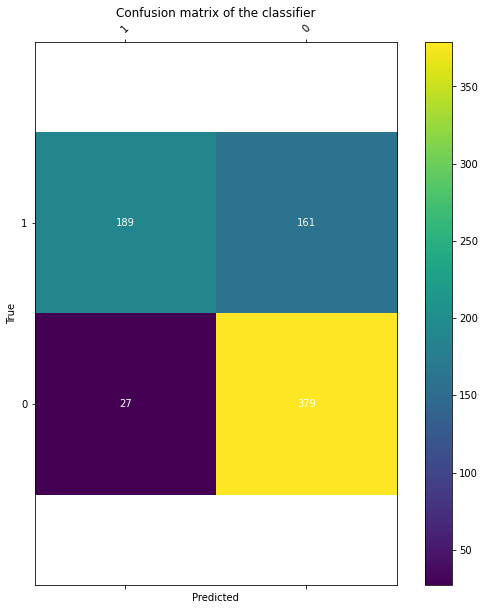

The false negative and false positive values are  [ 27 379]


In [13]:
from sklearn import metrics
import matplotlib.pyplot as plt
import numpy as np
def confusion_matrix_heatmap(y_test, preds, labels):
    """Function to plot a confusion matrix"""
    global cm 
    cm = metrics.confusion_matrix(y_test, preds, labels = labels)
    fig = plt.figure(figsize=(10,10))
    ax = fig.add_subplot(111)
    cax = ax.matshow(cm)
    plt.title('Confusion matrix of the classifier')
    fig.colorbar(cax)
    ax.set_xticks(np.arange(len(labels)))
    ax.set_yticks(np.arange(len(labels)))
    ax.set_xticklabels( labels, rotation=45)
    ax.set_yticklabels( labels)

    for i in range(len(cm)):
        for j in range(len(cm)):
            text = ax.text(j, i, cm[i, j],
                           ha="center", va="center", color="w")

    plt.xlabel('Predicted')
    plt.ylabel('True')
    
    # fix for mpl bug that cuts off top/bottom of seaborn viz:
    b, t = plt.ylim() # discover the values for bottom and top
    b += 0.5 # Add 0.5 to the bottom
    t -= 0.5 # Subtract 0.5 from the top
    plt.ylim(b, t) # update the ylim(bottom, top) values
    plt.show() # ta-da!
    plt.show()

confusion_matrix_heatmap(y_true, preds, labels = ['1','0'])
print("The false negative and false positive values are ",cm[1])

Training Classifier...
False positive and False negative values for one fold of validation dataset are  258 25


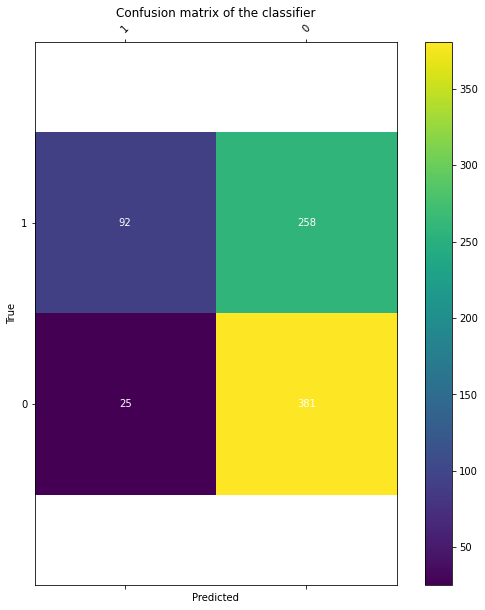

In [14]:
from sklearn import metrics
#considering one fold of data
myValData_1 = myValData[0:(fold_size)]
myTrainData_1 = myTrainData[0:(fold_size)]
#classifier for only one fold
classifier11 = train_classifier(myTrainData_1)
y_true1 = [x[1] for x in myValData_1]
y_data1 = [x[0] for x in myValData_1]
preds1 = predict_labels(y_data1, classifier11 )
cm11 = metrics.confusion_matrix(y_true1, preds1,labels = ['1','0'])
print("False positive and False negative values for one fold of validation dataset are ",cm11[0][1], cm11[1][0])
confusion_matrix_heatmap(y_true1, preds1, labels = ['1','0'])

In [15]:
functions_complete = True # set to True only when executing test data
if functions_complete:
    
    classifier = train_classifier(train_data)
    test_pred = predict_labels(test_data, classifier) 
    predict = []
    test_data_f= pd.read_csv('/kaggle/input/nlp-getting-started/test.csv')
    test_data_final = test_data_f['id']
    test_data_list = test_data_final.values.tolist()
    for (i,j) in zip(test_data_list, test_pred):
    # Testing the model on the test data to get predicted labels
     predict.append((i,j))

    submission = pd.DataFrame(predict, columns=['id','target'])

    submission.to_csv('submission.csv', index=False)

    pd.read_csv('submission.csv')

    display(submission)

    
     

Training Classifier...


,id,target
0,0,1
1,2,0
2,3,1
3,9,0
4,11,1
...,...,...
3258,10861,0
3259,10865,1
3260,10868,1
3261,10874,1
